# GPR Placed Above a Two-Layered Earth Model, and Parametric Simulations

In this notebook we will extend the model to a two layered medium representation of the Earth. Its solution is also comparable by a semi-analytical reference solution. () 

Further, we will demonstrate that using the Python I/O wrapper we can run multiple simulations iteratively that vary one or more input parameters. In this example, the parameter varied is the thickness of the PML.

## 1. Imports, Path and Platform Configuration

These imports to the I/O module, the path and platform configurations are similar to the first example.

In [ ]:
import os
from pathlib import Path

# inputs
from elfe3d_gpr_io.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)

MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = "",
    use_wsl    = False,
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


## 2: Generating the Geophysical Model

We will use a similar geometrical model as the second example notebook, except add a second layer below the homogeneous first layer. 

This new material is set to have a relative electric permittivity $\varepsilon_r$ of $9$, electrical conductivity $\sigma$ of $1e\text{-}3$ S/m, and is non-magnetic.

The two layers are now of thickness $1$ m and $\lambda_{air}/30$ respectively. It was found that this thin second layer is enough to give an accurate solution due to the high density of the mesh elements (as the mesh element edge lengths are governed by their dielectric permittivity using the `least_samples_per_wavelength`).

In [2]:
f    = 100e6
wave = 3e8 / f     # 3.0 m in air

survey = GPRSurvey.build(
    experiment_name = 'two_layered_earth',
    base_dir        = MASTER_PATH,

    # Domain
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-1.0 - wave/10/3, wave/10],

    # Material definition (air/free-space)
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    # Material definition (earth layers)
    layer_thicknesses = [1.0,    wave/30],   # layer 1: 1 m,  layer 2: thin half-space
    layer_eps_r       = [4.0,    9.0],
    layer_sigma       = [1e-4,   1e-3],
    layer_mu_r        = [1.0,    1.0],
    layer_sigma_m     = [0.0,    0.0],

    # Source
    f_list              = [f],
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 10,
)

survey.generate()
# print('poly :', survey.io.poly_file)


Source antenna length: 0.0006 m
Receiver antenna depth: -0.00015 m
Input generation complete.


> Note how the `least_samples_per_wavelength` variable is now even lower to `10` than the `20` from homogeneous half-space model. It is possible that the presence of higher dielectric material and their corresponding denser mesh sampling requirements allow this reduction. Due to the unstructured meshing creating transition regions between media of different dielectric permittivity, a higher dielectric material present will make its surroundings adequately sampled. 

## 3. Mesh generation with `tetgen`

We generate the mesh based on the inputs - same as before.

In [3]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_two_layered_earth.poly.
Delaunizing vertices...
Delaunay seconds:  0.002692
Creating surface mesh ...
Surface mesh seconds:  0.001233
Constrained Delaunay...
Constrained Delaunay seconds:  0.001576
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.00019
Refining mesh...
Refinement seconds:  0.745275
Optimizing mesh...
Optimization seconds:  0.03727

Writing GPR_model_two_layered_earth.1.node.
Writing GPR_model_two_layered_earth.1.ele.
Writing GPR_model_two_layered_earth.1.face.
Writing GPR_model_two_layered_earth.1.edge.
Writing GPR_model_two_layered_earth.1.vtk.
Writing GPR_model_two_layered_earth.1.neigh.

Output seconds:  0.628628
Total running seconds:  1.41696

Statistics:

  Input points: 242
  Input facets: 127
  Input segments: 369
  Input holes: 0
  Input regions: 45

  Mesh points: 44263
  Mesh tetrahedra: 266114
  Mesh faces: 535673
  Mesh edges: 313821
  Mesh faces on facets: 32729
  Mesh edges on segments: 182

## 4. Run the Fortran solver

We now have all simulation inputs ready. Hence, we can run the simulation now.

In [ ]:
run_solver(paths,survey)

## 5. Load solver results
Once the simulation is completed running, `elfe3d_gpr_io` can read the results.

In [5]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
# print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR two layered earth', # Changed label for plotting
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


r : 0.100 - 1.000 m   (48 receivers)


## 6. Analytical reference

In [6]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_9_100MHz_NR.csv'),
    label='Semi-Analytical',
).endfire()


## 7. Compare computed field to analytical reference

### 7.1. Plotting the base receiver-line data against analytical solution

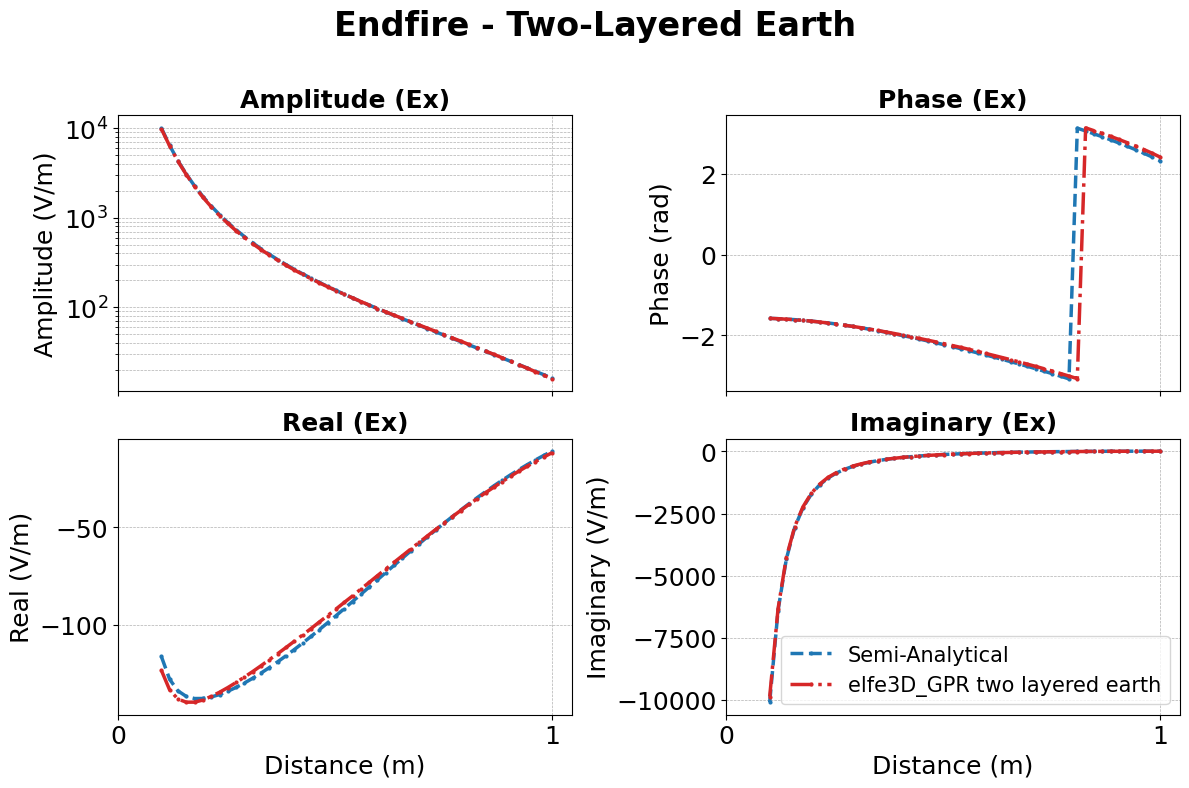

In [7]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Two-Layered Earth")

### 7.2. Error plot and quality check

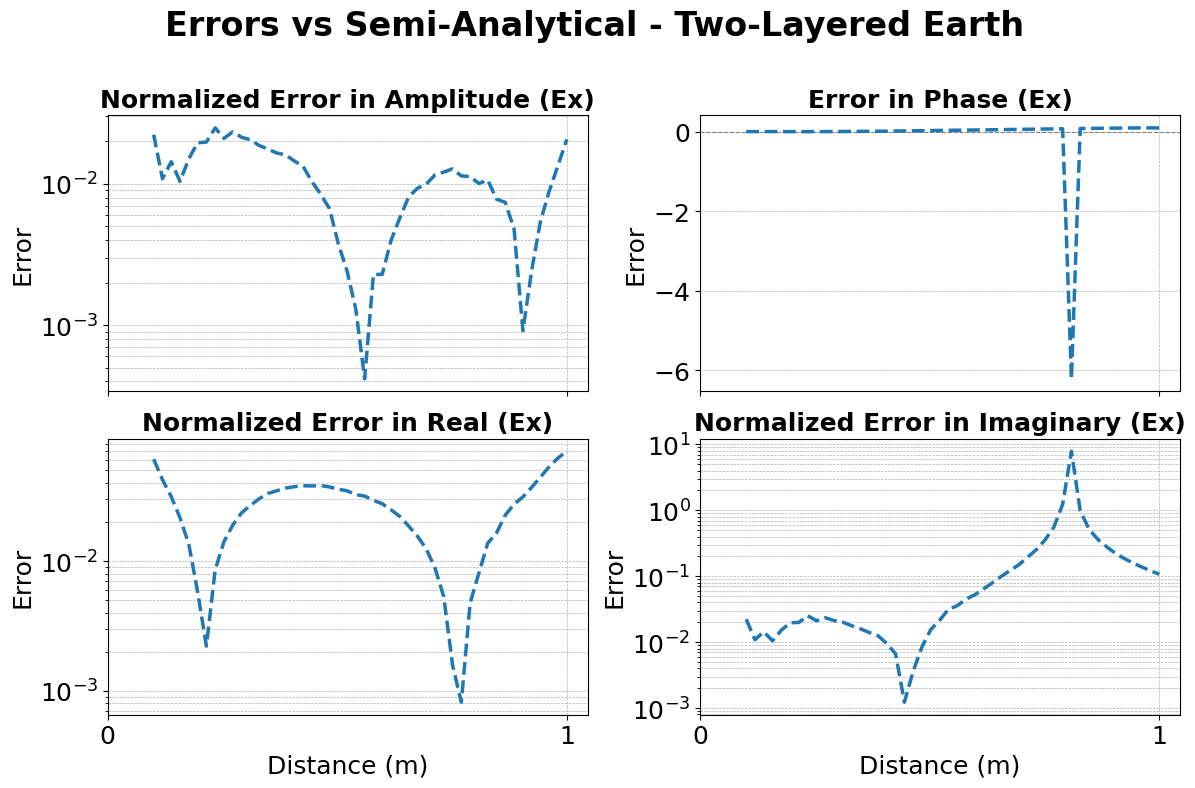

In [8]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Two-Layered Earth")

### 7.3 Combined field and error plot

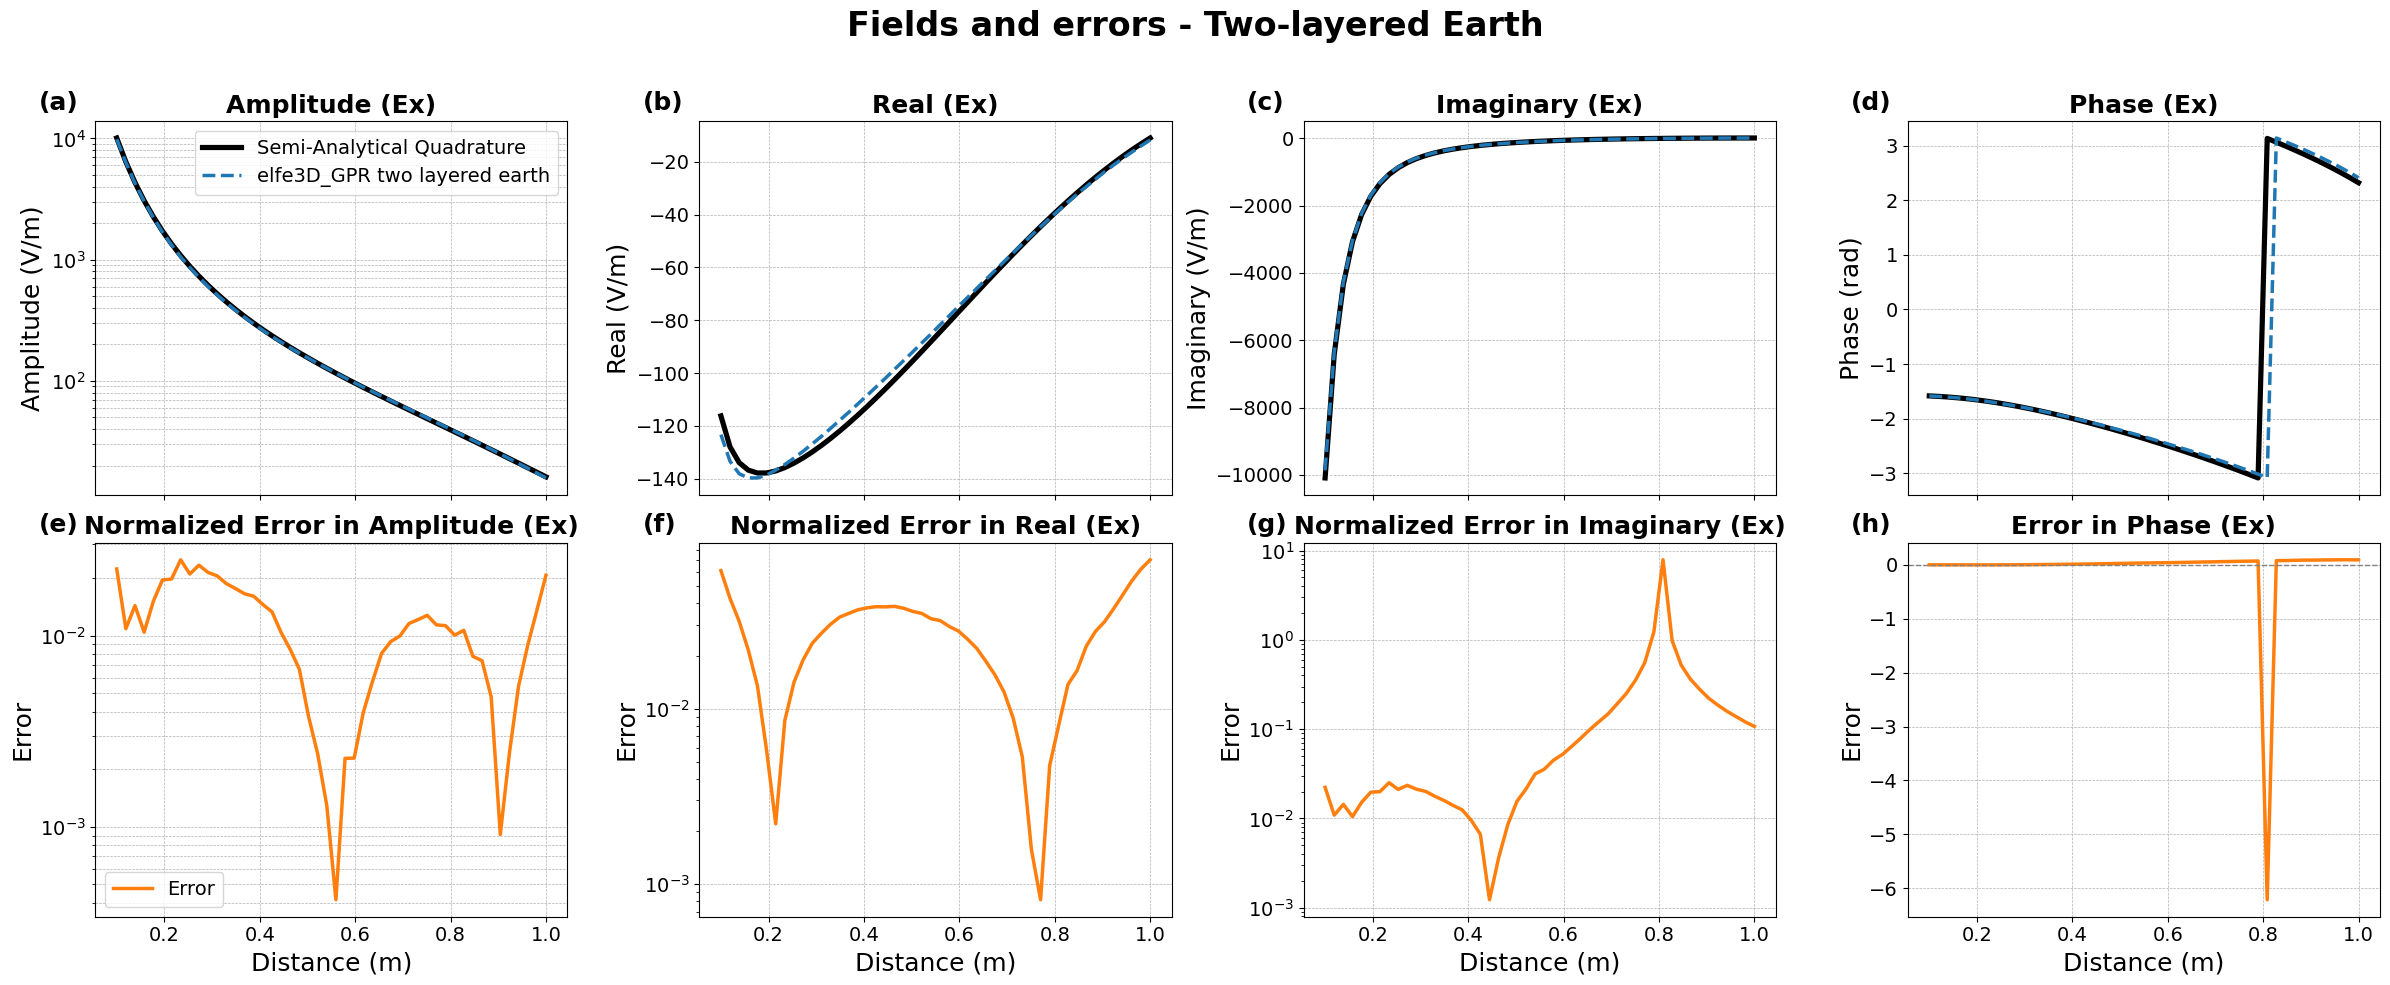

In [9]:
ReceiverLineCombined(ef, semi_analytical).plot(suptitle="Fields and errors - Two-layered Earth")

### 7.4. Error distribution histogram

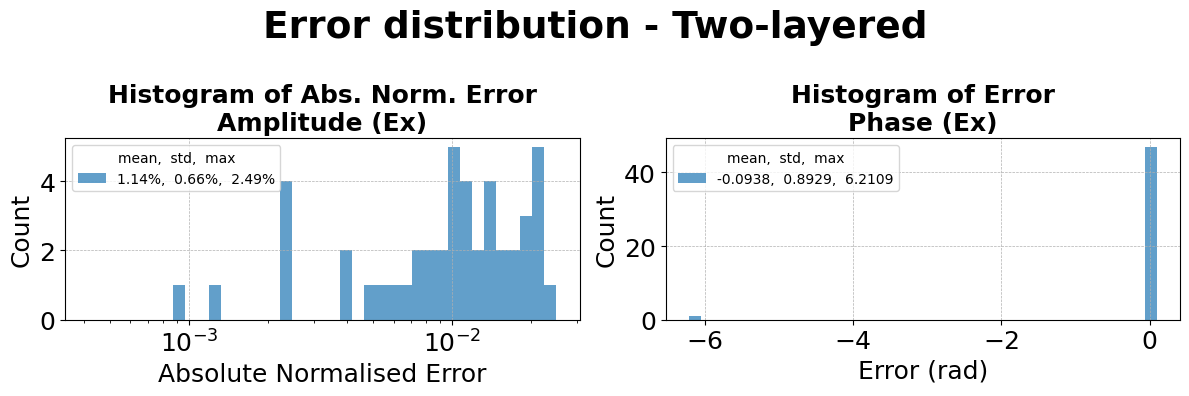

In [10]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle="Error distribution - Two-layered")

## 8. PML Thickness Parametric Simulations

Using the `elfe3d_gpr_io` module, it is possible to automate several simulations together to understand the effect of variation of one or more input parameters.

In this example, we conduct a PML thickness parametric study by running the same two-layer model for several PML thicknesses expressed as $\lambda_{layer\_2} / n$ where $\lambda_{layer\_2}$ is the wavelength in the second layer for the frequency of simulation. 

For each iteration, a new `GPRSurvey` object is built and run. By automating the naming of the experiment using the `experiment_name` variable, new output folders are created to ensure that they do not get overwritten.

### 8.a. Set up the list of parametric simulations

In [11]:
from elfe3d_gpr_io.outputs.visualize import ErrorStatPlot
import numpy as np

# lambda_layer_2 = wave / sqrt(eps_r_layer_2) = 3.0 / 3.0 = 1.0 m
wavelength_2            = 3e8 / (100e6 * np.sqrt(9.0))   # 1.0 m
simulation_frequency    = f
pml_thickness_factors   = [10, 12.5, 15, 17.5, 20, 22.5, 25]

# Each entry will be a separate survey with a different pml_layer_thickness
simulations_list = []
for f in pml_thickness_factors:
    s = GPRSurvey.build(
        experiment_name     = f'tl_pml_{str(f).replace(".", "p")}', # Automating naming of experiments
        base_dir            = MASTER_PATH,
        x_e = [-wave/10, 1 + wave/10],
        y_e = [-wave/10,     wave/10],
        z_e = [-1.0 - wave/10/3, wave/10],
        air_eps_r = 1.0,  air_sigma = 1e-16,
        layer_thicknesses = [1.0, wave/10/3],
        layer_eps_r  = [4.0,  9.0],
        layer_sigma  = [1e-4, 1e-3],
        layer_mu_r   = [1.0,  1.0],
        layer_sigma_m= [0.0,  0.0],
        f_list = [simulation_frequency],
        antenna_position    = [0.0, 0.0, 0.025],
        source_type=6, 
        current_direction=1, 
        num_segments=1,
        s_f=250, 
        bh_f=1.0, 
        box_present=False, 
        box_x=[-1+0.75, 1+0.375],
        num_receivers_inline=48,
        solver_type=2, 
        max_ref_steps=0, 
        max_unknowns=5_000_000,
        accuracy_tol=3e-5, 
        output_fields_vtk=1,
        num_pml_layers=1,
        pml_layer_thickness = wavelength_2 / f, # Iteratively changing PML thickness using factor f
        pml_type='lin', 
        pml_decay_type=1,
        least_samples_per_wavelength=20,
    )
    simulations_list.append(s)

print(f'Prepared {len(simulations_list)} simulations')
for s in simulations_list:
    print(f'  {s.io.experiment_name}  pml = {s.pml.layer_thickness:.4f} m')


Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Prepared 7 simulations
  tl_pml_10  pml = 0.1000 m
  tl_pml_12p5  pml = 0.0800 m
  tl_pml_15  pml = 0.0667 m
  tl_pml_17p5  pml = 0.0571 m
  tl_pml_20  pml = 0.0500 m
  tl_pml_22p5  pml = 0.0444 m
  tl_pml_25  pml = 0.0400 m


### 8.b. Run each simulation case:
Sequentially for now, but can be separately run.

In [ ]:
for s in simulations_list:
    print(f'\n>>> {s.io.experiment_name}')
    s.generate()
    run_tetgen(paths, s.io.poly_file)
    run_solver(paths, s)


### 8.c. Read results and plot

For parametric simulations, plotting classes like `ErrorStatPlot` are written in `elfe3d_gpr_io` module to plot some result values over a custom $x$-axis. Moreover, the functions such as `ReceiverLinePlot` and `ReceiverLinePlot` accept many simulation datasets by default.

In [13]:
simulation_datasets = []
for s, f in zip(simulations_list, pml_thickness_factors):
    result_txt = s.io.output_dir / 'electric_fields_receiver_line.txt'
    ds = ElfeLoader(
        filepath    = str(result_txt),
        label       = rf'$\lambda_2/{f}$',
        num_endfire = 48,
    ).endfire()
    simulation_datasets.append(ds)

print(f'Loaded {len(simulation_datasets)} simulation datasets')


Loaded 7 simulation datasets


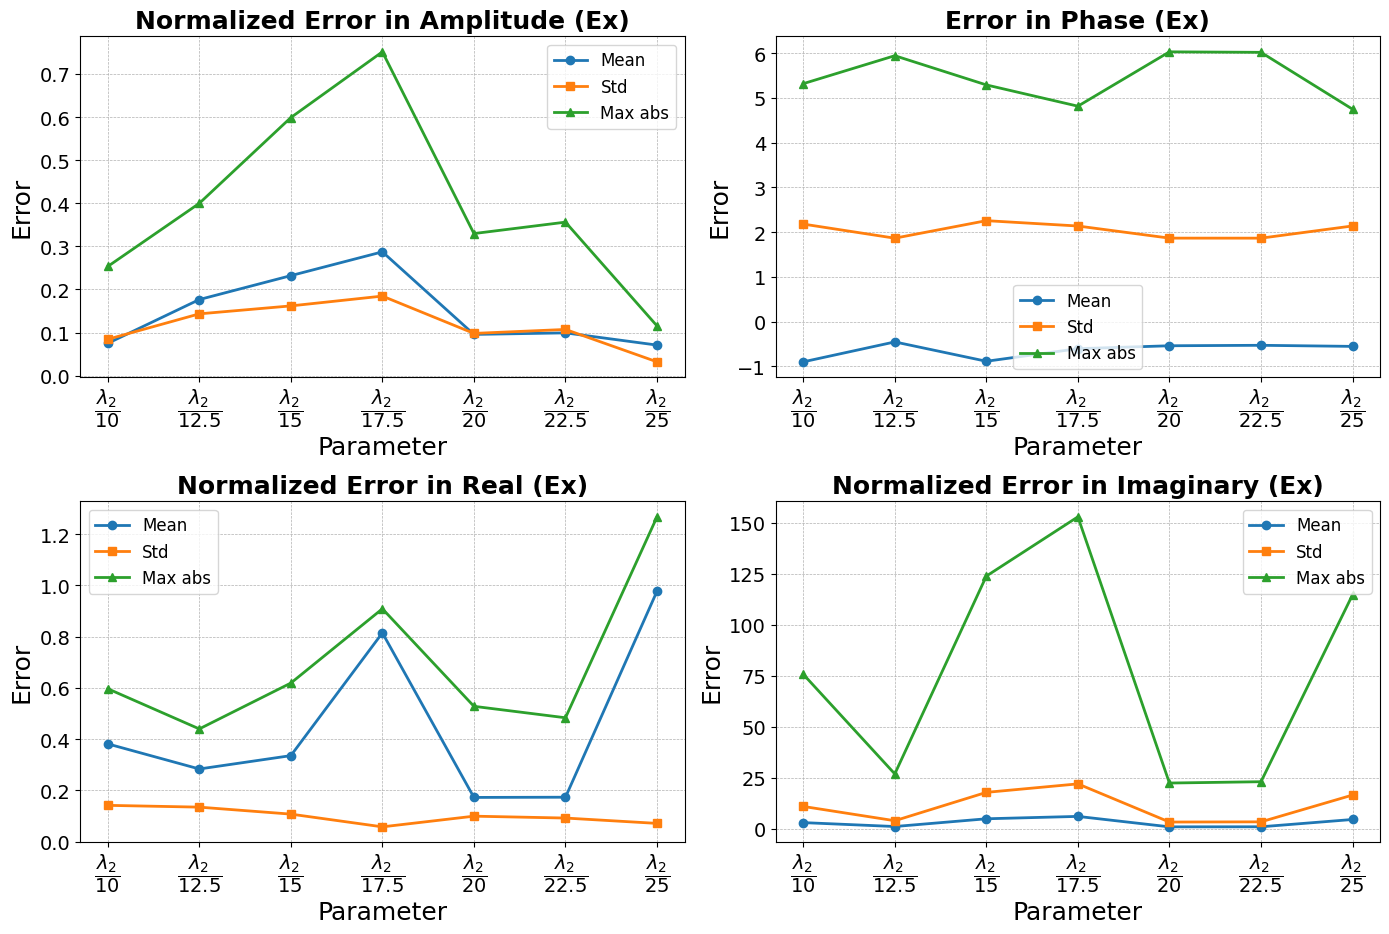

In [14]:
xtick_labels = [rf'$\dfrac{{\lambda_2}}{{{d}}}$' for d in pml_thickness_factors]

ErrorStatPlot(
    simulation_datasets,
    reference    = semi_analytical,
    param_values = [wavelength_2 / d for d in pml_thickness_factors],
    xtick_labels = xtick_labels,
).plot()


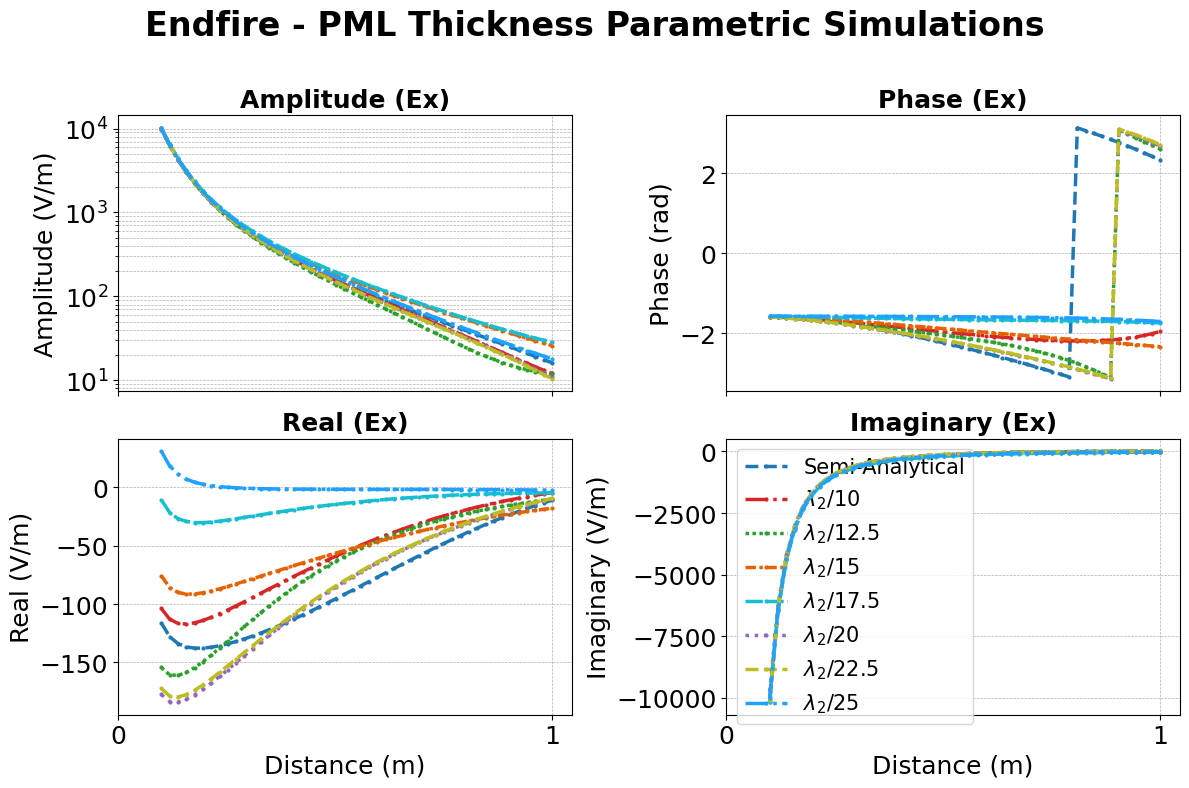

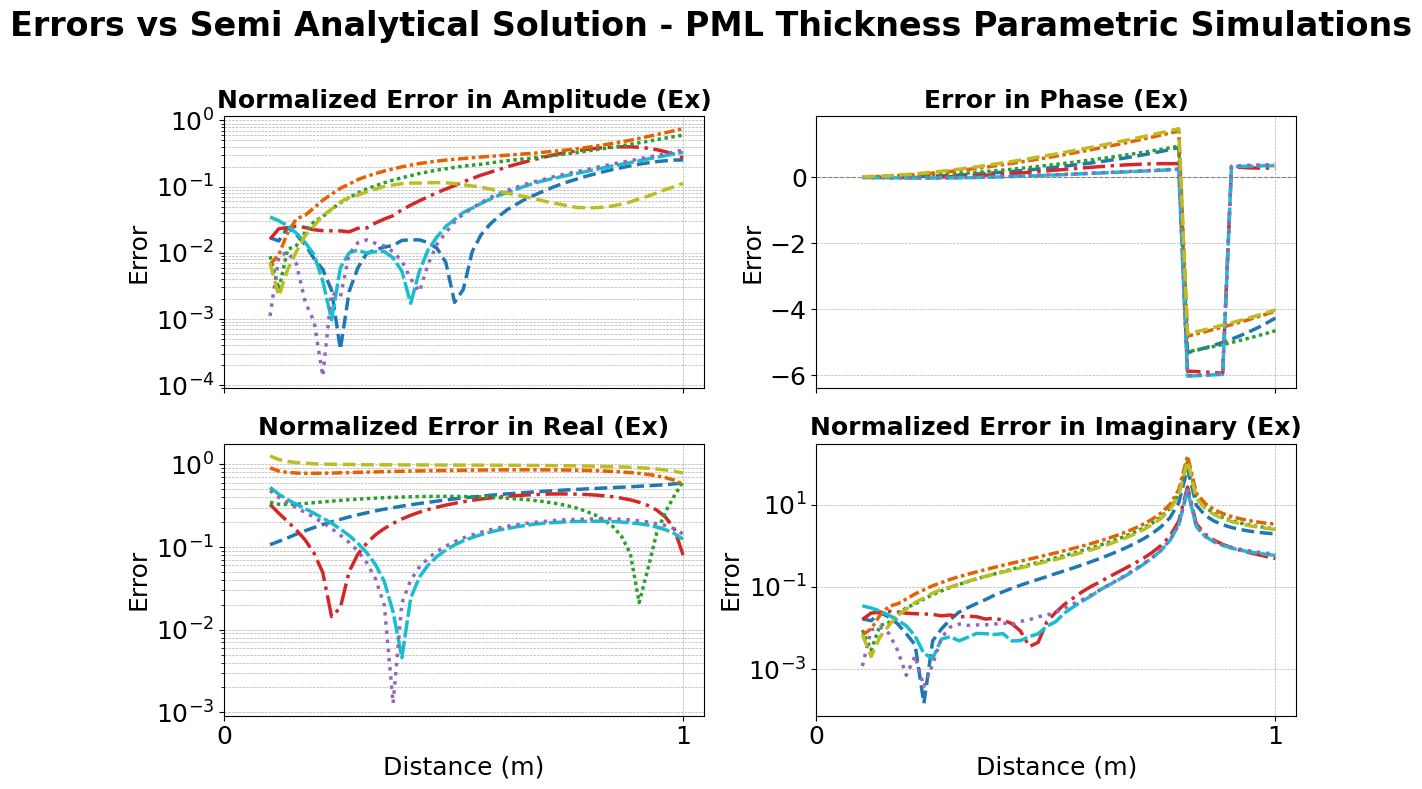

In [15]:
ReceiverLinePlot([semi_analytical] + simulation_datasets).plot(suptitle='Endfire - PML Thickness Parametric Simulations')
ReceiverLineErrorPlot(simulation_datasets, reference=semi_analytical).plot(suptitle='Errors vs Semi Analytical Solution - PML Thickness Parametric Simulations')


## 9. Conclusions

With this notebook we have shown that `elfe3D_GPR` is capable of layered media simulation, with very good accuracy, and how to perform parametric simulations to analyze one or more input parameters.